In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
# Install libraries
!pip install transformers peft accelerate -q

import torch
print(f" Device: {torch.cuda.get_device_name(0)}")
print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

 Device: Tesla T4
GPU Memory: 14.6 GB


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd
import numpy as np
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)
from peft import get_peft_model, LoraConfig, TaskType
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, f1_score
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Load data
train_df = pd.read_csv('/train_final.csv')
val_df = pd.read_csv('/val_final.csv')
test_df = pd.read_csv('/test_final.csv')

# Combine headline + content
train_df['text'] = train_df['headline'].fillna('') + ' ' + train_df['content'].fillna('')
val_df['text'] = val_df['headline'].fillna('') + ' ' + val_df['content'].fillna('')
test_df['text'] = test_df['headline'].fillna('') + ' ' + test_df['content'].fillna('')

# Label encoding
label2id = {'authentic': 0, 'fake': 1, 'ai_fake': 2}
id2label = {0: 'authentic', 1: 'fake', 2: 'ai_fake'}

train_df['label_id'] = train_df['label'].map(label2id)
val_df['label_id'] = val_df['label'].map(label2id)
test_df['label_id'] = test_df['label'].map(label2id)

# Remove NaN
train_df = train_df.dropna(subset=['text', 'label_id'])
val_df = val_df.dropna(subset=['text', 'label_id'])
test_df = test_df.dropna(subset=['text', 'label_id'])

print(" Data loaded!")
print(f"Train: {len(train_df)}")
print(f"Val:   {len(val_df)}")
print(f"Test:  {len(test_df)}")

 Data loaded!
Train: 10500
Val:   2250
Test:  2250


In [ ]:
# Load Llama tokenizer
import os
from dotenv import load_dotenv
load_dotenv()

HF_TOKEN = HF_TOKEN = os.getenv("HF_TOKEN")


print("Loading Llama tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    "meta-llama/Llama-3.2-1B",
    token=HF_TOKEN
)
tokenizer.pad_token = tokenizer.eos_token
print(" Tokenizer loaded!")

# Dataset class
class BanglaNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets
train_dataset = BanglaNewsDataset(
    train_df['text'].values,
    train_df['label_id'].values,
    tokenizer
)
val_dataset = BanglaNewsDataset(
    val_df['text'].values,
    val_df['label_id'].values,
    tokenizer
)
test_dataset = BanglaNewsDataset(
    test_df['text'].values,
    test_df['label_id'].values,
    tokenizer
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)
test_loader = DataLoader(test_dataset, batch_size=4)

print(" Datasets ready!")
print(f"Train batches: {len(train_loader)}")

Loading Llama tokenizer...


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

 Tokenizer loaded!
 Datasets ready!
Train batches: 2625


In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device: {device}")

 Device: cuda


In [11]:
# Load Llama model
print("Loading Llama model...")

model = AutoModelForSequenceClassification.from_pretrained(
    "meta-llama/Llama-3.2-1B",
    num_labels=3,
    torch_dtype=torch.float32,
    token=HF_TOKEN
)
model.config.pad_token_id = tokenizer.pad_token_id
model = model.to(device)

# LoRA config
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=4,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"]
)

# Apply LoRA
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
print(" Llama LoRA model ready!")

# Optimizer
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(), lr=1e-5)
total_steps = len(train_loader) * 3
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)
print(f"Total training steps: {total_steps}")

Loading Llama model...


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-3.2-1B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 432,128 || all params: 1,236,252,672 || trainable%: 0.0350
 Llama LoRA model ready!
Total training steps: 7875


In [12]:
# Training function
def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0

    for batch in loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    return total_loss / len(loader)

# Evaluation function
def evaluate(model, loader):
    model.eval()
    preds = []
    true_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            pred = outputs.logits.argmax(dim=1)
            preds.extend(pred.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    return preds, true_labels

# Train for 3 epochs
print("Training started!")
best_f1 = 0

for epoch in range(3):
    print(f"\nEpoch {epoch+1}/3")

    train_loss = train_epoch(model, train_loader, optimizer, scheduler)
    print(f"Train Loss: {train_loss:.4f}")

    val_preds, val_true = evaluate(model, val_loader)
    val_f1 = f1_score(val_true, val_preds, average='macro')
    print(f"Val Macro F1: {val_f1*100:.2f}%")

    if val_f1 > best_f1:
        best_f1 = val_f1
        model.save_pretrained('/llama_lora_best')
        print(f" Best model saved!")

print(f"\nBest Val F1: {best_f1*100:.2f}%")

Training started!

Epoch 1/3
Train Loss: 0.9288
Val Macro F1: 78.11%
 Best model saved!

Epoch 2/3
Train Loss: 0.5985
Val Macro F1: 80.17%
 Best model saved!

Epoch 3/3
Train Loss: 0.5713
Val Macro F1: 80.61%
 Best model saved!

Best Val F1: 80.61%


In [13]:
# Test evaluation
test_preds, test_true = evaluate(model, test_loader)

print("=== Llama 3.2 1B LoRA Test Results ===")
print(classification_report(
    test_true,
    test_preds,
    target_names=['authentic', 'fake', 'ai_fake']
))

test_f1 = f1_score(test_true, test_preds, average='macro')
print(f"Test Macro F1: {test_f1*100:.2f}%")

# Save model
model.save_pretrained('/llama_lora_best')
print(" Model saved to Drive!")

=== Llama 3.2 1B LoRA Test Results ===
              precision    recall  f1-score   support

   authentic       0.74      0.81      0.77       750
        fake       0.68      0.71      0.70       750
     ai_fake       0.94      0.80      0.86       750

    accuracy                           0.78      2250
   macro avg       0.79      0.78      0.78      2250
weighted avg       0.79      0.78      0.78      2250

Test Macro F1: 77.81%
 Model saved to Drive!


In [14]:
# Save model
model.save_pretrained('/content/drive/MyDrive/llama_lora_best')
print(" Model saved to Drive!")

 Model saved to Drive!


In [ ]:
import torch
import json
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score

# Load model from Drive
base_model = AutoModelForSequenceClassification.from_pretrained(
    "meta-llama/Llama-3.2-1B",
    num_labels=3,
    torch_dtype=torch.float32,
    token=HF_TOKEN
)
model = PeftModel.from_pretrained(
    base_model,
    'C:\\Users\\Riyad\\projects\\fake_news\\bloom_lora_best'  
)
model = model.to(device)
model.eval()
print(" Model loaded!")

# Quick F1 check
test_preds_list, test_true_list = evaluate(model, test_loader)
f1 = f1_score(test_true_list, test_preds_list, average='macro')
print(f"F1: {f1*100:.2f}%")

# Save predictions
with open('/content/drive/MyDrive/preds_llama.json', 'w') as f:
    json.dump({
        'preds': [int(p) for p in test_preds_list],
        'true': [int(t) for t in test_true_list]
    }, f)
print(" Predictions saved!")


C:\Users\Riyad\AppData\Roaming\Python\Python310\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
C:\Users\Riyad\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'HF_TOKEN' is not defined

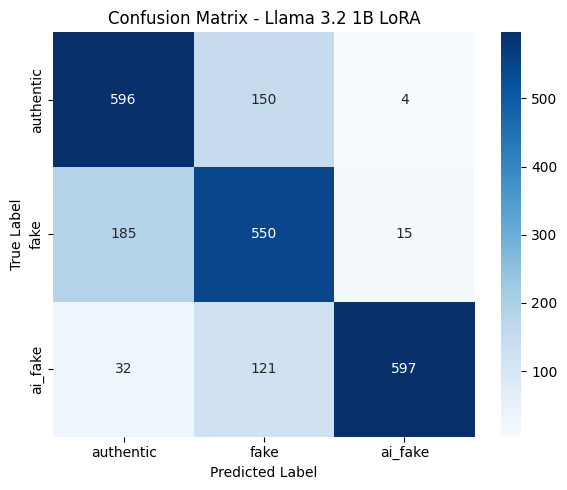

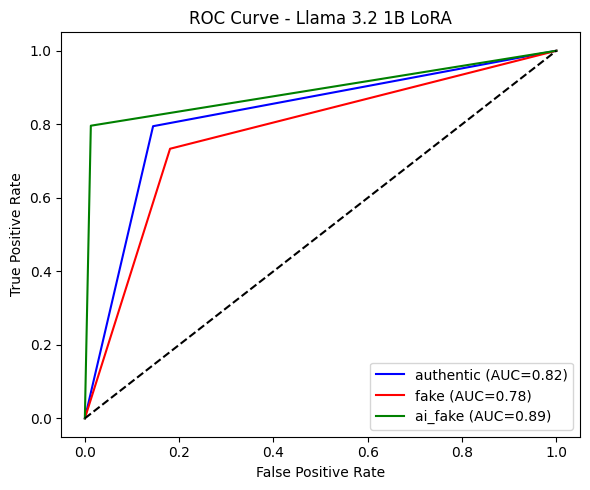

✅ Confusion Matrix & ROC Curve saved!


In [2]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Load predictions
with open('C:\\Users\\Riyad\\projects\\fake_news\\Lalama\\preds_llamaa (1).json', 'r') as f:
    data = json.load(f)

preds = data['preds']
true = data['true']

id2label = {0: 'authentic', 1: 'fake', 2: 'ai_fake'}
label_names = ['authentic', 'fake', 'ai_fake']

# ── Confusion Matrix ──
fig1, ax1 = plt.subplots(1, 1, figsize=(6, 5))
cm = confusion_matrix(true, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names, ax=ax1)
ax1.set_title('Confusion Matrix - Llama 3.2 1B LoRA')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('C:/Users/Riyad/projects/fake_news/cm_llama.png', dpi=300, bbox_inches='tight')
plt.show()

# ── ROC Curve ──
y_true_bin = label_binarize(true, classes=[0, 1, 2])
y_pred_bin = label_binarize(preds, classes=[0, 1, 2])

fig2, ax2 = plt.subplots(1, 1, figsize=(6, 5))
colors = ['blue', 'red', 'green']

for i, (cls, color) in enumerate(zip(label_names, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, color=color, label=f'{cls} (AUC={roc_auc:.2f})')

ax2.plot([0, 1], [0, 1], 'k--')
ax2.set_title('ROC Curve - Llama 3.2 1B LoRA')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(loc='lower right')
plt.tight_layout()
plt.savefig('C:/Users/Riyad/projects/fake_news/roc_llama.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Confusion Matrix & ROC Curve saved!")